# Simple Neural Networks on Real-World Data

This mini-project extends the ideas from the guide notebook on buiding NNs with Keras to a real-world medical dataset. You will load patient heart-health measurements, prepare them for modeling, and train a neural network that predicts whether heart disease is present.

## 0. Learning Goals

By the end of this mini-project you will be able to:
- Fetch a real-world CSV dataset directly inside Google Colab.
- Inspect the heart disease features and explain their meaning.
- Encode categorical medical descriptors with one-hot vectors.
- Build and evaluate a binary classification network with Keras.

## 1. Environment Setup

The next cell double-checks that TensorFlow (and the bundled Keras API) are available. Colab already provides them, but running it keeps your version info handy and seeds the random number generators for reproducible experiments.

In [ ]:
import tensorflow as tf
import numpy as np
import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


## 2. Fetch the Heart Disease Dataset
To fetch our dataset, we will use the [Kaggle](https://www.kaggle.com/) API so you can practice the same workflow you would follow for your own projects.

**What is Kaggle?** Kaggle is an online community where practitioners share datasets, host machine learning competitions, and publish example notebooks. Creating a free account unlocks the ability to download community datasets like the *Heart Failure Prediction* table we will use here.

Follow these steps the first time you use Kaggle:

1. **Create your account.** Visit [kaggle.com](https://www.kaggle.com/), click “Register,” and choose a username you like—it will also become part of your API credentials.
2. **Generate an API token.** After signing in, open your profile menu → **Settings** → **API** → click **Create New API Token**. Kaggle downloads a small file named `kaggle.json` that contains your username and a secret API key.


When you run the next cell in Google Colab:

- You will install Kaggle’s command line tool (`kaggle`).
- Paste your **username** and **API key** into the placeholder strings so the download can authenticate.
- The command `kaggle datasets download` fetches and unzips the dataset folder. We place the files in a `data/` directory and copy the `heart.csv` file next to this notebook for easy loading later.

> ⚠️ Colab does not remember environment variables or downloaded files between sessions. If you close the tab and return later, rerun this download cell.

In [ ]:
# Install the Kaggle command line interface (CLI)
!pip install -q kaggle

import os

# TODO: Replace the text inside the quotes with your own Kaggle username and API key.
# You can find them in the kaggle.json file you downloaded from your Kaggle account settings.
os.environ['KAGGLE_USERNAME'] = 'johnbernatavitz'
os.environ['KAGGLE_KEY'] = 'KGAT_6403bc7bb40a2814e65299ff548aaa53'

# Create a data directory (the -p flag skips creation if it already exists)
!mkdir -p data

# Download and unzip the Heart Failure Prediction dataset
!kaggle datasets download -d fedesoriano/heart-failure-prediction -p data --unzip

# Keep a copy of heart.csv in the same folder as this notebook for later steps
!cp data/heart.csv heart.csv

# List the files so you can verify the download worked
!ls data


Dataset URL: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
License(s): ODbL-1.0
  0% 0.00/8.56k [00:00<?, ?B/s]
100% 8.56k/8.56k [00:00<00:00, 28.1MB/s]
heart.csv


## 3. Peek at the Raw Data
To explore the dataset we will lean on [pandas](https://pandas.pydata.org/), a Python library designed for working with tabular data. Pandas introduces the **DataFrame**, a table-like object with labeled columns and rows, think of it as a programmable spreadsheet. DataFrames make it easy to sort, filter, and summarize data before we feed it into a neural network.

In this section we will use a handful of core pandas tools:

- `pandas.read_csv(...)` loads comma-separated values files into a DataFrame.
  - usage --> `df = pd.read_csv('data.csv')`
    - `df` is the loaded DataFrame
- `DataFrame.head()` returns the first few rows so we can spot-check the structure.
  - usage --> `df.head()`
- `DataFrame.info()` prints column names, data types, and counts to reveal missing values or categories.
  - usage --> `df.info()`
- `Series.value_counts()` tallies how often each label appears. Passing `normalize=True` converts those counts into proportions.
  - usage --> `counts_df = df['target_col'].value_counts(normalize=True)`
    - This returns a new DataFrame

As you read through the outputs, focus on understanding what each column represents and whether the values look reasonable. Getting comfortable with these quick checks will help you diagnose issues in future projects.


In [ ]:
# TODO: import pandas, typically aliased as pd
import pandas as pd


# TODO: Read the heart.csv into a pandas DataFrame
df = pd.read_csv('heart.csv')


### Preview the first few rows
The `.head()` method shows the first five rows of the `DataFrame` by default (you can pass a number to see more). This quick glance confirms that pandas loaded the file correctly and helps you match column names with the medical features described later in the notebook.

In [ ]:
# TODO: Use the .head method to view the first 5 rows of the heart DataFrame.

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Inspect column types with `df.info()`
Running the `.info()` method summarizes each column’s data type (integer, float, object, etc.) and how many non-missing values it contains. Neural networks expect numeric inputs, so this view helps you spot columns that may need encoding or cleaning.

In [ ]:
# TODO: Run the info method on the heart DataFrame to inspect column types and non-null counts.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Check the balance of the target labels
`df['HeartDisease'].value_counts(normalize=True)` counts how many samples fall into each class (0 for no heart disease, 1 for heart disease). Setting `normalize=True` divides each count by the total number of rows so you see percentages instead of raw counts. Finally, `.rename('proportion')` changes the output column label from the default `HeartDisease` to the more descriptive word “proportion.”

In [ ]:
# TODO: Calculate the normalized value counts for the HeartDisease column.
df['HeartDisease'].value_counts(normalize=True)


,proportion
HeartDisease,
1,0.553377
0,0.446623


### What each feature means

- **Age**: Patient age in years.
- **Sex**: Biological sex (`M` or `F`).
- **ChestPainType**: Clinical chest pain presentation: `ASY` (asymptomatic), `NAP` (non-anginal pain), `ATA` (atypical angina), `TA` (typical angina).
- **RestingBP**: Resting blood pressure in mm Hg.
- **Cholesterol**: Serum cholesterol in mg/dL.
- **FastingBS**: Fasting blood sugar flag (`1` if > 120 mg/dL, else `0`).
- **RestingECG**: Resting electrocardiogram results (`Normal`, `ST`, `LVH`).
- **MaxHR**: Maximum heart rate achieved during an exercise test.
- **ExerciseAngina**: Exercise-induced angina (`Y` or `N`).
- **Oldpeak**: ST depression induced by exercise relative to rest.
- **ST_Slope**: Slope of the peak exercise ST segment (`Up`, `Flat`, `Down`).
- **HeartDisease**: Target label (`1` indicates heart disease).

These features mix numerical measurements and categorical descriptors, so our preprocessing pipeline must handle both types gracefully.

## 4. Split and Encode the Features

Before we can train a neural network, we need to organize the features (inputs) and the target (output) in a way the model can understand. That involves **splitting** the dataset into training/validation/test subsets and **encoding** the columns so that numeric and categorical values live on comparable scales. Instead of manually repeating the same steps every time, we can build a reusable *preprocessing pipeline*.

A preprocessing pipeline is often called a **preprocessor**. It remembers whatever statistics it needs from the training set (for example, the mean and standard deviation for each numeric column) and then reuses those steps for the validation, test, or future data. In this case:

- Numeric columns will be standardized with `StandardScaler` so each one has mean 0 and standard deviation 1 on the training set.
- Categorical columns will be expanded with `OneHotEncoder(handle_unknown='ignore')`. This turns each possible category into its own indicator column without imposing an arbitrary numeric order. The `handle_unknown='ignore'` option keeps the pipeline from crashing if a new category appears later.

Walk through the workflow in steps:

1. Import the scikit-learn helpers we need.
2. Separate the feature matrix `X` from the target vector `y`.
3. Decide which columns should be treated as numeric versus categorical.
4. Split the dataset into training, validation, and test subsets.
5. Build a `ColumnTransformer` preprocessor that applies the right transformation to each group of columns.
6. Fit the preprocessor on the training data and transform every split.

Take your time with each step—understanding the *why* of the preprocessing is just as important as typing the correct code.

### 4.1 Import the preprocessing helpers

Scikit-learn provides ready-made utilities for the common preprocessing tasks we need. Importing them in their own cell makes it clear *which* tools we are relying on.

- `train_test_split` shuffles and slices arrays into the train/validation/test subsets.
  - From the `sklearn.model_selection` module
- `ColumnTransformer` lets us bundle multiple preprocessing steps together. For example,
  - `ColumnTransformer(transformers=[('num', StandardScaler(), ['RestingBP'])])` would apply a scaler only to the `RestingBP` column while leaving everything else untouched.
  - From the `sklearn.compose` module
- `StandardScaler` rescales numeric columns so they have mean 0 and standard deviation 1. You might see it used like
  - `StandardScaler().fit_transform(df[['Cholesterol']])` to normalize cholesterol readings.
  - From the `sklearn.preprocessing` module

- `OneHotEncoder` turns categories into 0/1 indicator columns, such as
  - `OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit_transform(df[['ChestPainType']])` producing one column per chest pain type.
  - From the `sklearn.preprocessing` module
  
Add the relevant import statements below, then run the cell.

In [ ]:
# TODO: Import train_test_split
import sklearn.model_selection
from sklearn.model_selection import train_test_split

# TODO: Import the ColumnTransformer
import sklearn.compose
from sklearn.compose import ColumnTransformer

# TODO: Import StandardScaler and OneHotEncoder
import sklearn.preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder

### 4.2 Separate the features (`X`) from the target (`y`)

Neural networks expect a matrix of input features `X` and a separate vector of target labels `y`.

1. Use `df_name.drop('target_column', axis=1)` (or an equivalent command) to make a copy of the DataFrame without the target column. This becomes `X`.
2. Grab the `target_column` column for `y` and convert it to `float32` so that TensorFlow receives the exact type it likes to work with.
  - `df_name['target_column']` will return a copy of the df with only the `target_column`.  Adding `.astype('float32')` will convert the returned copy to a 32-bit floating point number.

Remember that these commands do **not** modify the original `df`; they create new variables you can safely transform later.

In [ ]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease'].astype('float32')

Confirm that your input features matrix, and the target labels are correctly separated.  

*Hint: We learned how to view a portion of a DataFrame in an earlier step*

In [ ]:
# TODO: Display a preview of X to confirm the features DataFrame is constructed correctly.
X.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up


In [ ]:
# TODO: Display a preview of y to confirm the target Series is constructed correctly.
target_series_y_32.head()


,HeartDisease
0,0.0
1,1.0
2,0.0
3,1.0
4,0.0


### 4.3 Identify numeric versus categorical features

We will scale the columns that represent continuous measurements and one-hot encode the columns that represent categories. Looking back at the `df.info()` output can help you decide which is which.

- Numeric features include the measurements such as age and cholesterol level.
- Categorical features include fields such as chest pain type or ECG results that take on a small set of named categories.

Fill in the lists below with the appropriate column names. The order inside each list does not matter, but double-check the spelling so the pipeline can find the columns later.

In [ ]:
# TODO: Replace the placeholders below with the names of the numeric columns you want to scale.
num_features = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak'
]

# TODO: Replace the placeholders below with the names of the categorical columns you want to one-hot encode.
cat_features = [
    'Sex',
    'ChestPainType',
    'FastingBS',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

### 4.4 Split into training, validation, and test sets

We will follow a two-step split, mirroring the approach from the guide notebook:

1. Use `train_test_split` once to separate out the training set. Keep 30% of the rows in a temporary set that will eventually become validation + test data.
2. Use `train_test_split` a second time on that temporary set to carve it into equally sized validation and test sets.

Be sure to:

- Pass the `SEED` constant to the `random_state` argument for reproducibility.
- Set `stratify=y` (and later `stratify=y_temp`) so the class balance stays similar across splits. Stratification tells scikit-learn to sample each class in proportion to how often it appears in the full dataset, which keeps the heart disease label ratio consistent for training, validation, and testing. Without this safeguard you might accidentally create a validation set with very few positive cases, making performance estimates unreliable.

After you finish the splits, print the shapes to make sure they add up to the original dataset size.

In [ ]:
# TODO: First split X and y into a training set and a temporary set.
X_train, X_temp, y_train, y_temp = sklearn.model_selection.train_test_split(
    X, y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
)

# TODO: Split the temporary set into validation and test sets of equal size.
X_val, X_test, y_val, y_test = sklearn.model_selection.train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)


# TODO: Print out the shapes of each split to verify your work.
print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")


Training shape: (642, 11)
Validation shape: (138, 11)
Test shape: (138, 11)


### 4.5 Build the preprocessing pipeline

Now we can define the `ColumnTransformer` that ties everything together. The idea is to give the transformer a list of `(name, transformer, column_list)` tuples. Each tuple has three parts because scikit-learn needs to know **what the step is called**, **which transformer object to run**, and **which columns it should receive**. Using names keeps the pipeline readable, the transformer object holds the logic (like scaling or encoding), and the column list points to the exact DataFrame columns to feed into that logic.

- The first tuple should apply `StandardScaler()` to the numeric columns. `StandardScaler` subtracts the mean and divides by the standard deviation computed from the training data. This step keeps features such as age, cholesterol, and blood pressure on a comparable scale so the neural network does not favor features with larger raw numbers.

- The second tuple should apply `OneHotEncoder(sparse_output=False, handle_unknown='ignore')` to the categorical columns. Setting `sparse_output=False` returns a dense NumPy array that plays nicely with TensorFlow, and `handle_unknown='ignore'` ensures that categories only seen in the validation or test set do not crash the transformer.

Put both tuples in a list assigned to the `transformers` argument of `ColumnTransformer(transformers=transformers)`. Building the list first helps you see the structure clearly and makes it easy to tweak individual steps later (for example, to add scaling for a new numeric feature). Once the preprocessor is defined, it will output a NumPy array that contains all of the scaled and one-hot encoded features side by side.

In [ ]:
# TODO: Create the ColumnTransformer preprocessor described above
# and store it in a variable named preprocessor.
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
])

# After you define the preprocessor, you can display it to double-check the structure.
# You can do this by just referencing the preprocessor variable by name
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'RestingBP', 'Cholesterol', 'MaxHR',
                                  'Oldpeak']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Sex', 'ChestPainType', 'FastingBS',
                                  'RestingECG', 'ExerciseAngina',
                                  'ST_Slope'])])

### 4.6 Fit the preprocessor and transform each split

Only the training data should influence the fitted parameters inside the preprocessor. That means you should:

1. Call `fit_transform` on `X_train` to both learn the scaling/encoding rules **and** return the transformed training array.
   - `fit_transform` runs two steps back-to-back: `fit` captures statistics such as means for the scaler and category mappings for the encoder, then `transform` applies those learned rules to the training data immediately.
2. Call `transform` on `X_val` and `X_test` so they are processed using the *same* rules learned from the training data.
   - `transform` skips the learning phase and simply reuses the stored statistics from training, which is crucial for making fair comparisons between splits.

At the end, have the cell display `X_train_prepared.shape` as a quick check on the number of engineered features.

In [ ]:
# TODO: Fit the preprocessor on the training data and transform each split.
X_train_prepared = preprocessor.fit_transform(X_train)
X_val_prepared = preprocessor.transform(X_val)
X_test_prepared = preprocessor.transform(X_test)

# TODO: Inspect the dimensions of the transformed training data.
print(f"Original feature count: {X_train.shape[1]}")
print(f"Processed feature count: {X_train_prepared.shape[1]}")


Original feature count: 11
Processed feature count: 21


## 5. Build the Keras Model

With the encoded features ready, you can now build a binary classifier.

Monitor accuracy and area under the ROC curve (`AUC`).

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# TODO: Build your model
model = keras.Sequential([
    # Input layer shape matches the number of processed features
    layers.InputLayer(input_shape=(X_train_prepared.shape[1],)),

    # Hidden layer with ReLU activation
    layers.Dense(32, activation='relu'),

    # Dropout helps prevent overfitting by randomly setting inputs to 0 during training
    layers.Dropout(0.3),

    # Output layer: 1 unit with sigmoid for binary probability (0 to 1)
    layers.Dense(1, activation='sigmoid')
])


# TODO: Compile your model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)


# TODO: Display your models summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train with Early Stopping

`EarlyStopping` keeps an eye on the validation loss and restores the best weights once it stops improving. This guards against overfitting when the model starts memorizing the training data.

In the code cell, create an `EarlyStopping` object with three key parameters: `monitor='val_loss'` watches the validation loss each epoch, `patience=some_number` allows training to continue for `some_number` more epochs after the last improvement before stopping, and `restore_best_weights=True` reloads the weights from the epoch with the lowest validation loss. These choices balance patience (so the model has time to improve) with protection from wasting time on unhelpful epochs.

-  usage:
```python
patience_num = ...
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=patience_num,
    restore_best_weights=True
)
```

Keras expects callbacks like this to be passed as a list to the `callbacks` argument in `model.fit`. A **callback** is simply a hook that lets you run extra code at specific points during training (before/after each epoch, when training ends, etc.). By including `[early_stopping]` in the call to `model.fit`, you tell Keras to consult your early stopping rule every epoch and halt training when the validation loss plateaus while keeping the best-performing weights.

- usage:
```python
history = model.fit(
    ...
    callbacks=[early_stopping],
    ...
)
```

Train your model!

In [ ]:
# TODO: Configure EarlyStopping.
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
# TODO: Train the model.
history = model.fit(
    X_train_prepared, y_train,
    validation_data=(X_val_prepared, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - AUC: 0.5996 - accuracy: 0.6087 - loss: 0.6753 - val_AUC: 0.8024 - val_accuracy: 0.7319 - val_loss: 0.6117
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - AUC: 0.7923 - accuracy: 0.7318 - loss: 0.5904 - val_AUC: 0.8809 - val_accuracy: 0.8623 - val_loss: 0.5409
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - AUC: 0.8823 - accuracy: 0.7923 - loss: 0.5222 - val_AUC: 0.9061 - val_accuracy: 0.8768 - val_loss: 0.4828
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - AUC: 0.8941 - accuracy: 0.8398 - loss: 0.4739 - val_AUC: 0.9163 - val_accuracy: 0.8841 - val_loss: 0.4369
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - AUC: 0.9053 - accuracy: 0.8351 - loss: 0.4329 - val_AUC: 0.9204 - val_accuracy: 0.8841 - val_loss: 0.4033
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - AUC: 0.8997 - accuracy: 0.8182 - loss: 0.4211 - val_AUC: 0.9213 - val_accuracy: 0.8913 - val_loss: 0.3810
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0

## 7. Visualize the Learning Curves

Plotting the loss and accuracy traces makes it easier to diagnose how training is going. A healthy model usually has validation curves that follow the training curves without drifting far apart. Because plotting can feel abstract the first time you try it, we will slow down and set up the figure step by step.

### 7.1 Convert the training history into a DataFrame

The `history` object returned by Keras stores the loss and metrics for each epoch inside a dictionary named `history.history`. Converting that dictionary into a pandas DataFrame makes it easy to inspect the available columns and plot them.

Create the DataFrame and peek at the first few rows so you know exactly which column names to reference in the plots.

In [ ]:
# TODO: Turn history.history into a pandas DataFrame named history_df.
history_df = pd.DataFrame(history.history)

# TODO: Display the first five rows (for example, with history_df.head()) to confirm the column names.
display(history_df.head())


,AUC,accuracy,loss,val_AUC,val_accuracy,val_loss
0,0.635893,0.621495,0.658708,0.802427,0.731884,0.611653
1,0.804412,0.746106,0.579641,0.880881,0.862319,0.540885
2,0.872013,0.794393,0.519061,0.906110,0.876812,0.482834
3,0.892958,0.834891,0.467357,0.916330,0.884058,0.436919
4,0.895873,0.830218,0.439044,0.920375,0.884058,0.403251


### 7.2 Plot the loss and accuracy curves

Matplotlib's `plt.subplots` function can create a figure and one or more "axes" (the spaces where individual plots live). We want two axes in a single row—one for loss and one for accuracy.

Import `matplotlib.pyplot` (conventionally named `plt`) and create a figure with two axes. Storing the result in variables (for example, `fig, axes = plt.subplots(...)`) lets us reuse the axes in the next step.

With the axes ready, plot the training and validation metrics:

- On the first axis (`axes[0]`), plot both the training loss and validation loss. Label the x-axis with `Epoch`, the y-axis with `Loss`, add a descriptive title, and include a legend so the two lines are easy to tell apart.
- On the second axis (`axes[1]`), plot the training and validation accuracy using the same idea.

Call `plt.tight_layout()` at the end so the titles and labels do not overlap.

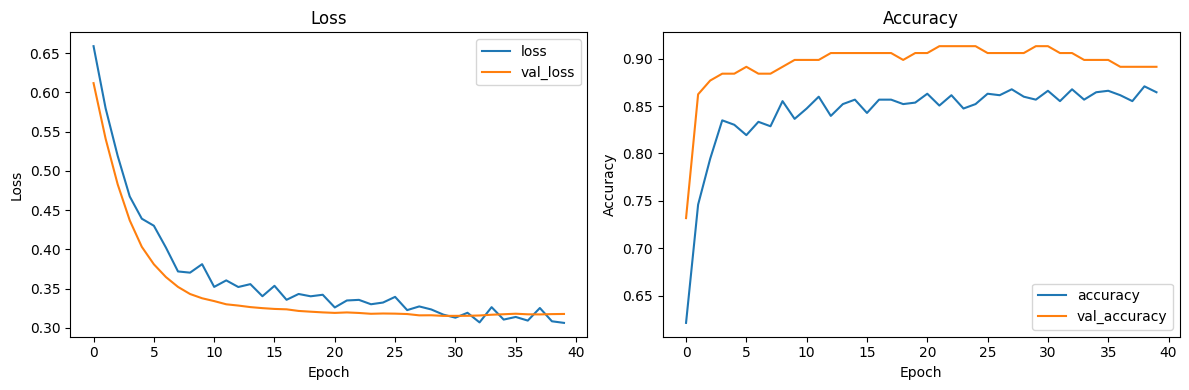

In [ ]:
# TODO: Import matplotlib.pyplot using the alias plt.
import matplotlib.pyplot as plt

# TODO: Use plt.subplots to create a figure with 1 row and 2 columns of Axes.
# Choose a figure size wide enough for both plots (something like (12, 4) works well).
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# TODO: Plot the training and validation loss on axes[0].
history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

# TODO: Plot the training and validation accuracy on axes[1].
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

# TODO: Use .tight_layout and .show to render
plt.tight_layout()
plt.show()


## 8. Evaluate on the Test Set

Keep the test set completely untouched until this point. Now we can report unbiased metrics and inspect a confusion matrix and classification report.

In [ ]:
test_loss, test_accuracy, test_auc = model.evaluate(X_test_prepared, y_test, verbose=0)
print(f'Test loss: {test_loss:.3f}')
print(f'Test accuracy: {test_accuracy:.3f}')
print(f'Test AUC: {test_auc:.3f}')

from sklearn.metrics import classification_report, confusion_matrix

y_test_proba = model.predict(X_test_prepared).ravel()
y_test_pred = (y_test_proba >= 0.5).astype('int32')

print('Classification report:', classification_report(y_test, y_test_pred))
print('Confusion matrix:', confusion_matrix(y_test, y_test_pred))

Test loss: 0.312
Test accuracy: 0.855
Test AUC: 0.946
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Classification report:               precision    recall  f1-score   support

         0.0       0.83      0.85      0.84        62
         1.0       0.88      0.86      0.87        76

    accuracy                           0.86       138
   macro avg       0.85      0.86      0.85       138
weighted avg       0.86      0.86      0.86       138

Confusion matrix: [[53  9]
 [11 65]]


## 9. Try a Fresh Prediction

With a trained model that performs reasonably well on the held-out test set, let’s generate some new predictions. The make_patient_prediction function below collects fresh patient data and passes it through the provided preprocessor and model. Simply pass your model and preprocessor to this function, and run it several times in the final cell to simulate real-world use. In a deployment scenario, you’d load the trained model and preprocessor from storage, then call this function on each incoming case.

In [ ]:
def make_patient_prediction(model, preprocessor):
    """Prompt for patient features, preprocess them, and display the model's prediction report."""
    import pandas as pd
    from IPython.display import display

    numeric_questions = [
        ('Age', {'prompt': 'Age (years)', 'type': int, 'min': 0, 'max': 120}),
        ('RestingBP', {'prompt': 'Resting blood pressure (mm Hg)', 'type': int, 'min': 0, 'max': 300}),
        ('Cholesterol', {'prompt': 'Serum cholesterol (mg/dL)', 'type': int, 'min': 0, 'max': 1000}),
        ('MaxHR', {'prompt': 'Max heart rate achieved', 'type': int, 'min': 0, 'max': 250}),
        ('Oldpeak', {'prompt': 'ST depression relative to rest (Oldpeak)', 'type': float, 'min': -2.0, 'max': 10.0}),
    ]

    categorical_questions = [
        ('Sex', ['M', 'F']),
        ('ChestPainType', ['ASY', 'NAP', 'ATA', 'TA']),
        ('FastingBS', ['0', '1']),
        ('RestingECG', ['Normal', 'ST', 'LVH']),
        ('ExerciseAngina', ['Y', 'N']),
        ('ST_Slope', ['Up', 'Flat', 'Down']),
    ]

    patient_data = {}

    for feature, settings in numeric_questions:
        while True:
            raw = input(f"{settings['prompt']}: ").strip()
            if not raw:
                print('Please provide a value before pressing enter.')
                continue
            try:
                value = float(raw)
            except ValueError:
                print('That entry is not numeric. Please try again.')
                continue
            if value < settings['min'] or value > settings['max']:
                print(f"Please enter a value between {settings['min']} and {settings['max']}.")
                continue
            if settings['type'] is int:
                if not value.is_integer():
                    print('Please enter a whole number for this field.')
                    continue
                value = int(value)
            else:
                value = float(value)
            patient_data[feature] = value
            break

    for feature, options in categorical_questions:
        option_lookup = {opt.lower(): opt for opt in options}
        formatted_options = ', '.join(options)
        while True:
            raw = input(f"{feature} ({formatted_options}): ").strip().lower()
            if not raw:
                print('Please choose one of the listed options.')
                continue
            if raw not in option_lookup:
                print(f"Invalid option. Please choose one of: {formatted_options}.")
                continue
            value = option_lookup[raw]
            if feature == 'FastingBS':
                patient_data[feature] = int(value)
            else:
                patient_data[feature] = value
            break

    feature_order = [
        'Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol',
        'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope'
    ]

    patient_df = pd.DataFrame([{feature: patient_data[feature] for feature in feature_order}])
    prepared = preprocessor.transform(patient_df)
    probability = float(model.predict(prepared, verbose=0)[0, 0])
    prediction_label = 'Heart Disease' if probability >= 0.5 else 'No Heart Disease'

    print("\nPatient inputs:")
    display(patient_df)

    print("\nModel prediction report:")
    print(f" • Probability of heart disease: {probability:.3f}")
    print(f" • Predicted class: {prediction_label}")

    return {'inputs': patient_df, 'probability': probability, 'prediction': prediction_label}


In [ ]:
make_patient_prediction(model, preprocessor)

Age (years): k
That entry is not numeric. Please try again.
Age (years): Age
That entry is not numeric. Please try again.
Age (years): 45
Resting blood pressure (mm Hg): 
Please provide a value before pressing enter.
Resting blood pressure (mm Hg): 425
Please enter a value between 0 and 300.
Resting blood pressure (mm Hg): 93
Serum cholesterol (mg/dL): 58
Max heart rate achieved: 58
ST depression relative to rest (Oldpeak): 1054
Please enter a value between -2.0 and 10.0.
ST depression relative to rest (Oldpeak): 10
Sex (M, F): m
ChestPainType (ASY, NAP, ATA, TA): nap
FastingBS (0, 1): 1
RestingECG (Normal, ST, LVH): normal
ExerciseAngina (Y, N): y
ST_Slope (Up, Flat, Down): up

Patient inputs:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,45,M,NAP,93,58,1,Normal,58,Y,10.0,Up



Model prediction report:
 • Probability of heart disease: 0.989
 • Predicted class: Heart Disease


{'inputs':    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
 0   45   M           NAP         93           58          1     Normal     58   
 
   ExerciseAngina  Oldpeak ST_Slope  
 0              Y     10.0       Up  ,
 'probability': 0.9890521764755249,
 'prediction': 'Heart Disease'}